# LeetCode #71: Simplify Path

https://leetcode.com/problems/simplify-path/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| String Replace Loops | O(n²) | O(n) | Repeated replacements for //, /./, /.. |
| **Stack (split by /) ★** | **O(n)** | **O(n)** | Split on /, push dirs, pop on .., skip . and empty |

---

## Understanding the Methods

### Brute Force (String Replace)
Repeatedly replace `//` → `/`, `/./` → `/`, then handle `..` with string searches. Fragile and O(n²) due to re-scanning.

### Optimal: Stack ★
1. Split path by `'/'` into tokens.
2. For each token:
   - `""` or `"."` → skip
   - `".."` → pop stack if non-empty (go to parent)
   - Any other name → push onto stack
3. Join stack with `'/'` and prepend `'/'`. Empty stack → return `"/"`.

**Constraints:**
* 1 <= path.length <= 3000
* path consists of English letters, digits, '.', '/', '_'
* path is a valid absolute Unix path

## Solutions

### C#

In [ ]:
public class Solution {
    public string SimplifyPath(string path) {
        var stack = new Stack<string>();
        foreach (var part in path.Split('/')) {
            if (part == "" || part == ".") continue;
            if (part == "..") {
                if (stack.Count > 0) stack.Pop();
            } else {
                stack.Push(part);
            }
        }
        return "/" + string.Join("/", stack.Reverse());
    }
}

### Python

In [ ]:
class Solution:
    def simplifyPath(self, path: str) -> str:
        stack = []
        for part in path.split('/'):
            if part == '' or part == '.':
                continue
            elif part == '..':
                if stack:
                    stack.pop()
            else:
                stack.append(part)
        return '/' + '/'.join(stack)

### Go

In [ ]:
func simplifyPath(path string) string {
    parts := strings.Split(path, "/")
    stack := []string{}
    for _, p := range parts {
        if p == "" || p == "." {
            continue
        } else if p == ".." {
            if len(stack) > 0 {
                stack = stack[:len(stack)-1]
            }
        } else {
            stack = append(stack, p)
        }
    }
    return "/" + strings.Join(stack, "/")
}

### Rust

In [ ]:
impl Solution {
    pub fn simplify_path(path: String) -> String {
        let mut stack: Vec<&str> = Vec::new();
        for part in path.split('/') {
            match part {
                "" | "." => {}
                ".." => { stack.pop(); }
                name => stack.push(name),
            }
        }
        format!("/{}", stack.join("/"))
    }
}

## Example Scenarios

### 1. Common Case — Simple Nested Path
**Input:** `"/home/user/docs/file.txt"`

Split produces tokens: `["", "home", "user", "docs", "file.txt"]`. Empty string skipped, all others pushed. Stack = `[home, user, docs, file.txt]`. Join with `/` and prepend `/`.

**Why it’s useful:** Confirms the basic push-and-join flow with no special tokens.

### 2. Slightly Complex — Mixed //, /./, and /../
**Input:** `"/home//foo/../bar/./baz///"`

Tokens: `["", "home", "", "foo", "..", "bar", ".", "baz", "", "", ""]`. Push home $\to$ push foo $\to$ pop foo (..) $\to$ push bar $\to$ skip (.) $\to$ push baz. Final stack = `[home, bar, baz]`.

**Why it’s tricky:** Exercises all three skip conditions (empty, ".", "..") in one path. Multiple consecutive slashes produce multiple empty tokens.

### 3. Edge Case: Time Factor — 3000-Char Path with Maximum Tokens
**Input:** `"/a" * 1500` (1500 directories, path length $\approx 3000$)

Split produces $\approx 1500$ tokens, each processed in $O(1)$. Total work: $O(n)$ where $n = $ path length $= 3000$ (max constraint). Even appending 750 `".."` tokens to pop half back only doubles the constant.

**Why it’s tricky:** Stress-tests the max path length. The split itself is $O(n)$; the single pass over tokens is $O(n)$.

### 4. Edge Case: Space Factor — Full Reversal to Root
**Input:** `"/a/b/c/d/e/f/g/h/i/j/../../../../../../../../../../"`

Push 10 directories, then 10 `".."` tokens pop them all. Peak stack size = 10, final size = 0. Output: `"/"`. The join of an empty stack is `""`, so prepending `/` gives the root.

**Why it’s tricky:** Peak stack = $O(n)$ but result is minimal. Tests the empty-stack $\to$ root-slash edge.

### 5. Almost-Impossible but Plausible — Near-Miss Decoy Names
**Input:** `"/../../../.../..hidden/...x/./"`

Three `".."` at root are no-ops (can’t go above root). Then `"..."`, `"..hidden"`, `"...x"` are **valid directory names** — only exact `"."` and `".."` are special. Final stack = `[..., ..hidden, ...x]`. Output: `"/.../ ..hidden/...x"`.

**Why it’s tricky:** `"..."` looks like `".."` but is a 3-char name. `"..hidden"` starts with `".."` but is not it. A startsWith check instead of exact equality would incorrectly pop.


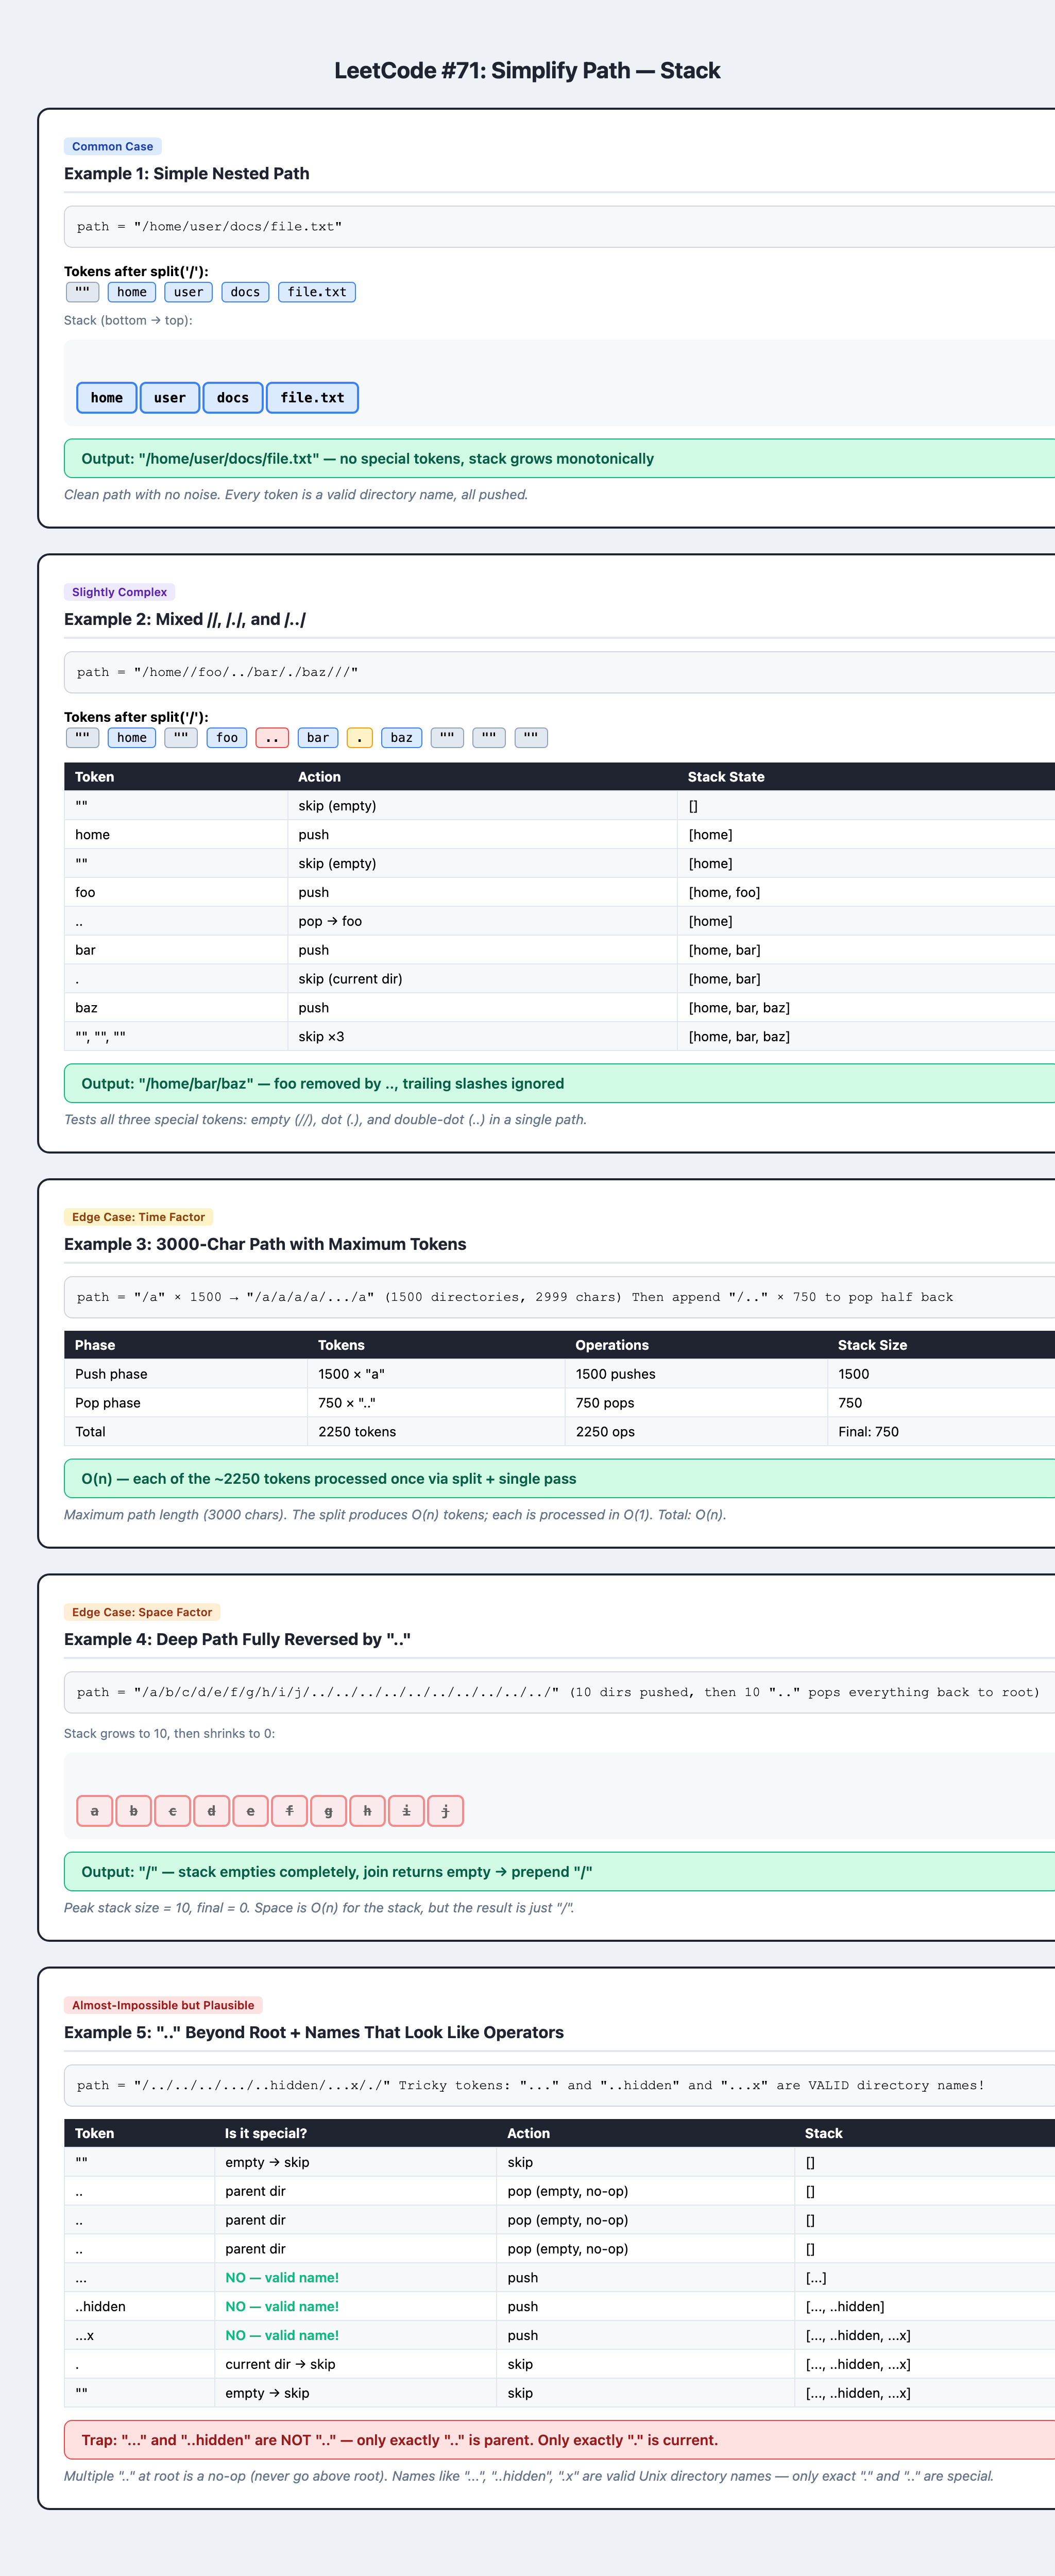